<a href="https://colab.research.google.com/github/nouur-mohaamed/CreditCardDefault_ML_Project/blob/main/Credit_card_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)


# Visualize the fetched data ( features and targets )

In [4]:
default_of_credit_card_clients.data

{'ids':           ID
 0          1
 1          2
 2          3
 3          4
 4          5
 ...      ...
 29995  29996
 29996  29997
 29997  29998
 29998  29999
 29999  30000
 
 [30000 rows x 1 columns],
 'features':            X1  X2  X3  X4  X5  X6  ...    X18    X19    X20   X21    X22   X23
 0       20000   2   2   1  24   2  ...      0    689      0     0      0     0
 1      120000   2   2   2  26  -1  ...      0   1000   1000  1000      0  2000
 2       90000   2   2   2  34   0  ...   1518   1500   1000  1000   1000  5000
 3       50000   2   2   1  37   0  ...   2000   2019   1200  1100   1069  1000
 4       50000   1   2   1  57  -1  ...   2000  36681  10000  9000    689   679
 ...       ...  ..  ..  ..  ..  ..  ...    ...    ...    ...   ...    ...   ...
 29995  220000   1   3   1  39   0  ...   8500  20000   5003  3047   5000  1000
 29996  150000   1   3   2  43  -1  ...   1837   3526   8998   129      0     0
 29997   30000   1   2   2  37   4  ...      0      0  22000  42

In [5]:
features=default_of_credit_card_clients.data.features
features

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [6]:
targets=default_of_credit_card_clients.data.targets
targets

,Y
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


In [7]:
full_credit_card_data_table=pd.concat([features,targets],axis=1)
full_credit_card_data_table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


# playing with pandas data frame

In [8]:
print(full_credit_card_data_table[['X1','X15']].head()) # get multiple columns (panda data frame 'subset')

       X1    X15
0   20000      0
1  120000   3272
2   90000  14331
3   50000  28314
4   50000  20940


In [9]:
print(full_credit_card_data_table[['X3']].head()) # get one column (pandas series)

   X3
0   2
1   2
2   2
3   2
4   2


In [10]:
full_credit_card_data_table.loc[[0,5,7]] # get rows 0, 5, 7

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
5,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,0


In [11]:
full_credit_card_data_table.loc[[4]] # get row 4 as a data frame

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [12]:
full_credit_card_data_table.loc[4] # get row 4 as a series (where column names are indices)

,4
X1,50000
X2,1
X3,2
X4,1
X5,57
X6,-1
X7,0
X8,-1
X9,0
X10,0


In [13]:
full_credit_card_data_table.iloc[2:6,3] # get column of index 3 (column X4) from row 0f index 2 till row of index 5 (excluding row of index 6)

,X4
2,2
3,1
4,1
5,2


# understanding the data set

In [14]:
full_credit_card_data_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [15]:
full_credit_card_data_table.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


know the data types of features

In [16]:
full_credit_card_data_table.dtypes

,0
X1,int64
X2,int64
X3,int64
X4,int64
X5,int64
X6,int64
X7,int64
X8,int64
X9,int64
X10,int64


testing null values

In [17]:
full_credit_card_data_table.isnull().sum() # no null values

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


testing duplicate rows

In [18]:
full_credit_card_data_table.duplicated().sum()

np.int64(35)

testing the balance of data

In [19]:
full_credit_card_data_table['Y'].value_counts() # get the count of classes in a column

,count
Y,
0,23364
1,6636


In [20]:
not_default=full_credit_card_data_table['Y'].value_counts()[0]
default=full_credit_card_data_table['Y'].value_counts()[1]
print(f"the percentage of the not default: {round((not_default/(default+not_default))*100)}%")
print(f"the percentage of the default: {round((default/(default+not_default))*100)}%")

the percentage of the not default: 78%
the percentage of the default: 22%


<Axes: xlabel='Y'>

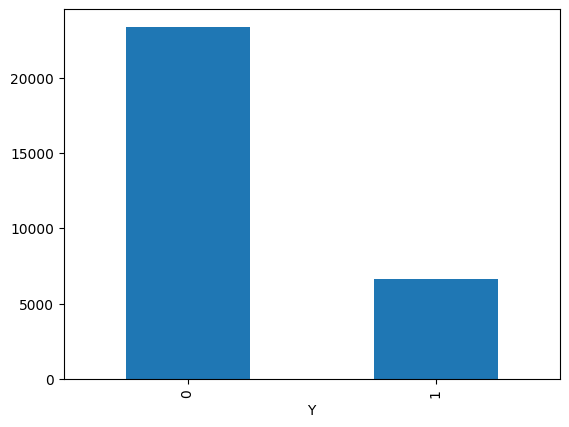

In [21]:
full_credit_card_data_table['Y'].value_counts().plot(kind='bar') # data is imbalanced

# DAY 1 REPORT
*   number of samples: 30,000
*   number of features: 23
*   Target : default? [ 1--> yes , 0--> no ]
*   missing values : no
*   Numerical features: Amount of the given credit,Age,Amount of bill statement,Amount of previous payment
*   Categorical features: Gender,Education,Marital status,History of past payment
* Class 0 percentage: 78%
* Class 1 percentage: 22%
### features meaning:
* Amount of the given credit [X1]: the credit limit given to that person (can't exceed)
* Amount of bill statement [X12-X17]: how much does he owe the bank at this month report
* Amount of previous payment[X18-X23]: how much of what he was owed did he pay at this month report
* History of past payment[X6 - X11]: what is his payment status at this month report ( was he delayed or not and by how many months was he delayed)






# preprocessing

create a modified copy of the data set with binary encoding

In [22]:
full_credit_card_data_table_encoded=full_credit_card_data_table.copy()

In [23]:
full_credit_card_data_table_encoded['X2']=full_credit_card_data_table_encoded['X2'].replace([1,2],[0,1]) # male-> 0 / female-> 1
full_credit_card_data_table_encoded

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,1,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,1,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,1,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,1,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,0,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,0,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,0,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,0,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,0,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [24]:
marital_status_data = []
for marital_status in full_credit_card_data_table_encoded['X4']:
  if marital_status==1:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':0
    })
  elif marital_status==2:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':1
    })
  else:
    marital_status_data.append({
        'marital_status_msb':1,
        'marital_status_lsb':0
    })
marital_status_df = pd.DataFrame(marital_status_data)
marital_status_df

,marital_status_msb,marital_status_lsb
0,0,0
1,0,1
2,0,1
3,0,0
4,0,0
...,...,...
29995,0,0
29996,0,1
29997,0,1
29998,0,0


In [25]:
table_target=full_credit_card_data_table_encoded['Y']
full_credit_card_data_table_encoded.drop(columns=['X4','Y'],inplace=True)
full_credit_card_data_table_encoded=pd.concat([full_credit_card_data_table_encoded,marital_status_df,table_target],axis=1)
full_credit_card_data_table_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,marital_status_msb,marital_status_lsb,Y
0,20000,1,2,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,0,0,1
1,120000,1,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,0,1,1
2,90000,1,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,1,0
3,50000,1,2,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,0,0
4,50000,0,2,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,0,3,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0,0,0
29996,150000,0,3,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0,1,0
29997,30000,0,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,0,1,1
29998,80000,0,3,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,0,0,1


# Train and Test Split ( not encoded )

In [26]:
from sklearn.model_selection import train_test_split

split train and test without solving the imbalance just yet, only considering that the same ratio between two classes is maintained both in train and test data using stratified

In [27]:
train,test=train_test_split(full_credit_card_data_table,test_size=0.2,random_state=42,stratify=full_credit_card_data_table['Y'])

make sure the same proportions is preserved (double checking step)

In [28]:
print(train['Y'].value_counts()/train.shape[0])
print(test['Y'].value_counts()/test.shape[0])

Y
0    0.778792
1    0.221208
Name: count, dtype: float64
Y
0    0.778833
1    0.221167
Name: count, dtype: float64


In [29]:
y_train=train['Y']
y_test=test['Y']
x_train=train.drop(columns=['Y'])
x_test=test.drop(columns=['Y'])

# Train and Test Split ( encoded )

In [30]:
train_encoded,test_encoded=train_test_split(full_credit_card_data_table_encoded,test_size=0.2,random_state=42,stratify=full_credit_card_data_table_encoded['Y'])

In [31]:
y_train_encoded=train_encoded['Y']
y_test_encoded=test_encoded['Y']
x_train_encoded=train_encoded.drop(columns=['Y'])
x_test_encoded=test_encoded.drop(columns=['Y'])

# scaling the numerical features only (not encoded)

* numerical features---> scaling
* categorical features---> encoding (if needed)

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
num_features=['X1','X5','X12','X13','X14','X15','X16','X17','X18','X19','X20','X21','X22','X23']

In [34]:
scaler=StandardScaler()
x_train[num_features]=scaler.fit_transform(x_train[num_features])
x_test[num_features]=scaler.transform(x_test[num_features])

In [35]:
x_test

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
6907,-0.906231,1,2,2,1.149244,-1,-1,-1,-1,0,0,-0.674215,-0.324008,-0.685090,-0.632468,-0.607727,-0.605522,1.265573,-0.290332,-0.099569,-0.164029,-0.199755,-0.133832
24575,-0.134081,1,1,1,-0.482066,-1,-1,-2,-2,-2,-1,-0.491106,-0.691886,-0.685090,-0.673845,-0.662488,-0.454951,-0.348251,-0.290332,-0.297820,-0.318075,0.460127,1.387682
26766,-0.906231,1,2,2,-1.134590,0,0,0,0,0,0,-0.041295,-0.009278,0.031389,0.106055,0.170133,0.202774,-0.236782,-0.199282,-0.172200,-0.185276,-0.197362,-0.178818
2156,0.946928,2,1,2,-1.134590,0,0,0,0,0,0,3.465211,3.595337,3.647850,3.210915,3.328879,3.241563,0.580657,0.228121,0.273178,0.677916,0.204281,1.014180
3179,2.568442,2,2,1,-0.917082,-2,-2,-2,-2,-2,-2,-0.540706,-0.550960,-0.486706,-0.517706,-0.497544,-0.483514,0.269968,0.380546,0.273178,0.345919,0.347555,1.124601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8836,-0.134081,2,5,2,-0.917082,-2,-2,-1,-1,0,-1,-0.529497,-0.376465,0.269992,-0.356367,-0.523391,-0.477916,1.042139,2.952517,0.865189,-0.316415,0.371677,-0.019547
1259,-0.906231,1,1,2,-1.243344,2,2,0,0,0,0,-0.015706,-0.002884,-0.020363,-0.358006,-0.350744,-0.330649,-0.348251,-0.187679,-0.258250,-0.246364,-0.270461,-0.236746
27309,0.406423,1,1,2,-0.155804,0,0,-1,-1,-1,0,-0.496711,-0.597460,-0.616905,-0.525044,1.287250,1.239810,-0.037315,-0.059547,0.246341,7.649851,-0.316978,-0.292992
29583,-0.365726,1,1,2,-1.025836,-1,-1,-1,-2,-1,-1,-0.662760,-0.679407,-0.685090,-0.673845,-0.490188,-0.652126,-0.293508,-0.290332,-0.297820,0.375533,-0.316978,-0.292992


In [36]:
x_train

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
22788,-0.056866,2,2,2,-0.264558,2,2,3,2,0,0,1.505547,1.745089,1.778869,1.891679,2.020839,2.096346,0.580657,-0.290332,-0.297820,0.086961,0.500397,0.048745
29006,-0.134081,2,1,2,-0.155804,1,-1,-1,-2,-2,-2,-0.695165,-0.691138,-0.685090,-0.673845,-0.662488,-0.652126,-0.344969,-0.290332,-0.297820,-0.318075,-0.316978,-0.292992
16950,-1.215090,1,2,1,1.584260,1,2,0,0,0,0,-0.556800,-0.576836,-0.561615,-0.547887,-0.526789,-0.510492,-0.348128,-0.227081,-0.233069,-0.298554,-0.296710,-0.236970
22280,0.406423,2,1,2,-0.699574,0,0,0,0,0,0,2.119190,2.287237,2.460102,2.738001,1.509166,1.613118,0.215287,0.154056,0.152526,0.000642,0.008643,0.043143
11346,1.101358,2,1,2,-0.373312,1,-2,-1,0,0,-2,-0.695165,-0.691886,-0.680324,-0.668755,-0.666365,-0.656089,-0.348251,-0.274236,-0.297820,-0.318075,-0.316978,-0.225765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23479,-0.520156,2,2,2,-0.482066,0,0,0,0,0,0,0.547467,0.611202,0.695283,0.848294,0.947432,0.987481,-0.143334,-0.072039,0.015430,-0.092317,-0.081667,-0.074841
13921,-0.365726,2,2,2,-1.243344,0,0,0,0,0,2,0.833040,0.908244,1.003664,1.105331,1.351925,1.404308,-0.088157,-0.087889,-0.063711,0.345919,-0.013951,-0.292992
3794,-0.365726,2,1,2,-1.243344,0,0,0,0,0,0,0.335954,0.381031,0.297140,0.105665,-0.115072,-0.317835,-0.119121,-0.190444,-0.182707,-0.185276,-0.237234,-0.236970
27565,1.487433,1,1,1,2.345538,1,-2,-1,-1,-1,-2,-0.695165,-0.691886,-0.672517,-0.670004,-0.663247,-0.652902,-0.348251,-0.247869,-0.283773,-0.318075,-0.316978,-0.292992


# scaling the numerical features only (encoded)

In [37]:
x_train_encoded[num_features]=scaler.fit_transform(x_train_encoded[num_features])
x_test_encoded[num_features]=scaler.transform(x_test_encoded[num_features])

In [38]:
x_train_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,marital_status_msb,marital_status_lsb
22788,-0.056866,1,2,-0.264558,2,2,3,2,0,0,1.505547,1.745089,1.778869,1.891679,2.020839,2.096346,0.580657,-0.290332,-0.297820,0.086961,0.500397,0.048745,0,1
29006,-0.134081,1,1,-0.155804,1,-1,-1,-2,-2,-2,-0.695165,-0.691138,-0.685090,-0.673845,-0.662488,-0.652126,-0.344969,-0.290332,-0.297820,-0.318075,-0.316978,-0.292992,0,1
16950,-1.215090,0,2,1.584260,1,2,0,0,0,0,-0.556800,-0.576836,-0.561615,-0.547887,-0.526789,-0.510492,-0.348128,-0.227081,-0.233069,-0.298554,-0.296710,-0.236970,0,0
22280,0.406423,1,1,-0.699574,0,0,0,0,0,0,2.119190,2.287237,2.460102,2.738001,1.509166,1.613118,0.215287,0.154056,0.152526,0.000642,0.008643,0.043143,0,1
11346,1.101358,1,1,-0.373312,1,-2,-1,0,0,-2,-0.695165,-0.691886,-0.680324,-0.668755,-0.666365,-0.656089,-0.348251,-0.274236,-0.297820,-0.318075,-0.316978,-0.225765,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23479,-0.520156,1,2,-0.482066,0,0,0,0,0,0,0.547467,0.611202,0.695283,0.848294,0.947432,0.987481,-0.143334,-0.072039,0.015430,-0.092317,-0.081667,-0.074841,0,1
13921,-0.365726,1,2,-1.243344,0,0,0,0,0,2,0.833040,0.908244,1.003664,1.105331,1.351925,1.404308,-0.088157,-0.087889,-0.063711,0.345919,-0.013951,-0.292992,0,1
3794,-0.365726,1,1,-1.243344,0,0,0,0,0,0,0.335954,0.381031,0.297140,0.105665,-0.115072,-0.317835,-0.119121,-0.190444,-0.182707,-0.185276,-0.237234,-0.236970,0,1
27565,1.487433,0,1,2.345538,1,-2,-1,-1,-1,-2,-0.695165,-0.691886,-0.672517,-0.670004,-0.663247,-0.652902,-0.348251,-0.247869,-0.283773,-0.318075,-0.316978,-0.292992,0,0


In [39]:
x_test_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,marital_status_msb,marital_status_lsb
6907,-0.906231,0,2,1.149244,-1,-1,-1,-1,0,0,-0.674215,-0.324008,-0.685090,-0.632468,-0.607727,-0.605522,1.265573,-0.290332,-0.099569,-0.164029,-0.199755,-0.133832,0,1
24575,-0.134081,0,1,-0.482066,-1,-1,-2,-2,-2,-1,-0.491106,-0.691886,-0.685090,-0.673845,-0.662488,-0.454951,-0.348251,-0.290332,-0.297820,-0.318075,0.460127,1.387682,0,0
26766,-0.906231,0,2,-1.134590,0,0,0,0,0,0,-0.041295,-0.009278,0.031389,0.106055,0.170133,0.202774,-0.236782,-0.199282,-0.172200,-0.185276,-0.197362,-0.178818,0,1
2156,0.946928,1,1,-1.134590,0,0,0,0,0,0,3.465211,3.595337,3.647850,3.210915,3.328879,3.241563,0.580657,0.228121,0.273178,0.677916,0.204281,1.014180,0,1
3179,2.568442,1,2,-0.917082,-2,-2,-2,-2,-2,-2,-0.540706,-0.550960,-0.486706,-0.517706,-0.497544,-0.483514,0.269968,0.380546,0.273178,0.345919,0.347555,1.124601,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8836,-0.134081,1,5,-0.917082,-2,-2,-1,-1,0,-1,-0.529497,-0.376465,0.269992,-0.356367,-0.523391,-0.477916,1.042139,2.952517,0.865189,-0.316415,0.371677,-0.019547,0,1
1259,-0.906231,0,1,-1.243344,2,2,0,0,0,0,-0.015706,-0.002884,-0.020363,-0.358006,-0.350744,-0.330649,-0.348251,-0.187679,-0.258250,-0.246364,-0.270461,-0.236746,0,1
27309,0.406423,0,1,-0.155804,0,0,-1,-1,-1,0,-0.496711,-0.597460,-0.616905,-0.525044,1.287250,1.239810,-0.037315,-0.059547,0.246341,7.649851,-0.316978,-0.292992,0,1
29583,-0.365726,0,1,-1.025836,-1,-1,-1,-2,-1,-1,-0.662760,-0.679407,-0.685090,-0.673845,-0.490188,-0.652126,-0.293508,-0.290332,-0.297820,0.375533,-0.316978,-0.292992,0,1


# LDA

In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [41]:
from sklearn.metrics import accuracy_score ,confusion_matrix

In [42]:
LDA=LinearDiscriminantAnalysis()
LDA.fit(x_train,y_train)

LinearDiscriminantAnalysis()

In [43]:
prediction=LDA.predict(x_test)

In [44]:
accuracy_score(y_test,prediction)

0.8086666666666666

In [45]:
confusion_matrix(y_test,prediction)

array([[4514,  159],
       [ 989,  338]])

for encoded data

In [46]:
LDA_for_encoded=LinearDiscriminantAnalysis()
LDA_for_encoded.fit(x_train_encoded,y_train_encoded)

LinearDiscriminantAnalysis()

In [47]:
prediction_encoded=LDA_for_encoded.predict(x_test_encoded)

In [48]:
accuracy_score(y_test_encoded,prediction_encoded)

0.8091666666666667